In [1]:
# Python import
import os
import copy
import random
import itertools
import numpy as np
import pandas as pd
import lightgbm as lgb
import warnings
import joblib
from sklearn.model_selection import train_test_split,RandomizedSearchCV
import sklearn.metrics as metrics
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
import lightgbm as lgb
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from scipy.stats import uniform, randint
from ngboost import NGBClassifier
from catboost import CatBoostClassifier
from ngboost.distns import k_categorical
from xgboost import XGBClassifier

/lulabdata3/huangkeyun/miniconda/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
def ligate_sequence(seq, add_len):
    seq = str(seq)
    seqlen = len(seq)
    if seqlen >= add_len:
        extra = seq[:add_len]
    else:
        repeat_times = add_len // seqlen
        remainder = add_len % seqlen
        extra = seq * repeat_times + seq[:remainder]
    return seq + extra

In [3]:
def balance_dataset_by_tag(df, tag_column='tag', random_state=42):
    """
    df : pd.DataFrame
        需要处理的原始数据集。
    tag_column : str, 默认 'tag'
        用于分割数据的列名，默认是 'tag'。
    random_state : int, 默认 42
    返回:
    pd.DataFrame
        平衡后的数据集，tag列为0和1的行数一致。
    """
    # 分割数据集为 tag=0 和 tag=1 的两部分
    df_tag_0 = df[df[tag_column] == 0]
    df_tag_1 = df[df[tag_column] == 1]

    # 判断哪个数据集较大，然后对较大的数据集进行下采样
    if len(df_tag_0) > len(df_tag_1):
        df_tag_0_downsampled = resample(df_tag_0, 
                                        replace=False,  # 不允许重复采样
                                        n_samples=len(df_tag_1),  # 调整为与tag=1一致
                                        random_state=random_state)  # 设置随机种子
        df_balanced = pd.concat([df_tag_0_downsampled, df_tag_1])
    else:
        df_tag_1_downsampled = resample(df_tag_1, 
                                        replace=False,  # 不允许重复采样
                                        n_samples=len(df_tag_0),  # 调整为与tag=0一致
                                        random_state=random_state)  # 设置随机种子
        df_balanced = pd.concat([df_tag_0, df_tag_1_downsampled])

    # 打乱数据集的顺序
    df_balanced = df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)

    return df_balanced


In [4]:
# Count the frequency of k-mer in each RNA sequence
# k-mer was normalized by total k-mer count of each RNA sequence
def _count_kmer(Dataset, k):  # k = 3, 4, 5
    
    # copy dataset
    dataset = copy.deepcopy(Dataset)
    # alphabet of nucleotide
    nucleotide = ['A', 'C', 'G', 'T']
    
    # generate k-mers
    #  k == 5:
    five = list(itertools.product(nucleotide, repeat=5))
    pentamer = [''.join(n) for n in five]
    
    #  k == 4:
    four = list(itertools.product(nucleotide, repeat=4))
    tetramer = [''.join(n) for n in four]

    # k == 3:
    three = list(itertools.product(nucleotide, repeat=3))
    threemer = [''.join(n) for n in three]
    
    # input features can be combinations of different k values
    if k == 34:
        table_kmer = dict.fromkeys(threemer, 0)
        table_kmer.update(dict.fromkeys(tetramer, 0))
    elif k == 45:
        table_kmer = dict.fromkeys(tetramer, 0)
        table_kmer.update(dict.fromkeys(pentamer, 0))
    elif k == 345:
        table_kmer = dict.fromkeys(threemer, 0)
        table_kmer.update(dict.fromkeys(tetramer, 0))
        table_kmer.update(dict.fromkeys(pentamer, 0))

    # count k-mer for each sequence
    for mer in table_kmer.keys():
        table_kmer[mer] = dataset["Sequence"].apply(lambda x: x.count(mer))
    
    # for k-mer raw count without normalization, index: nuc:1 or cyto:0
    rawcount_kmer_df = pd.DataFrame(table_kmer)
    df1_rawcount = pd.concat([rawcount_kmer_df, dataset["RNA_Symbol"]], axis=1)
    df1_rawcount.index = dataset["tag"]

    # for k-mer frequency with normalization, index: nuc:1 or cyto:0
    freq_kmer_df = rawcount_kmer_df.apply(lambda x: x / x.sum(), axis=1)
    df1 = pd.concat([freq_kmer_df, dataset["RNA_Symbol"]], axis=1)
    df1.index = dataset["tag"]

    return df1, df1_rawcount


In [5]:
#Evaluate performance of model
def evaluate_performance(y_test, y_pred, y_prob):
    # AUROC
    auroc = metrics.roc_auc_score(y_test,y_prob)
    auroc_curve = metrics.roc_curve(y_test, y_prob)
    # AUPRC
    auprc=metrics.average_precision_score(y_test, y_prob) 
    auprc_curve=metrics.precision_recall_curve(y_test, y_prob)
    #Accuracy
    accuracy=metrics.accuracy_score(y_test,y_pred) 
    #MCC
    mcc=metrics.matthews_corrcoef(y_test,y_pred)
    
    recall=metrics.recall_score(y_test, y_pred)
    precision=metrics.precision_score(y_test, y_pred)
    f1=metrics.f1_score(y_test, y_pred)
    class_report=metrics.classification_report(y_test, y_pred,target_names = ["control","case"])

    model_perf = {"auroc":auroc,"auroc_curve":auroc_curve,
                  "auprc":auprc,"auprc_curve":auprc_curve,
                  "accuracy":accuracy, "mcc": mcc,
                  "recall":recall,"precision":precision,"f1":f1,
                  "class_report":class_report}
        
    return model_perf

In [6]:
# Output result of evaluation
def eval_output(model_perf,path):
    with open(os.path.join(path,"Evaluate_Result_TestSet.txt"),'w') as f:
        f.write("AUROC=%s\tAUPRC=%s\tAccuracy=%s\tMCC=%s\tRecall=%s\tPrecision=%s\tf1_score=%s\n" %
               (model_perf["auroc"],model_perf["auprc"],model_perf["accuracy"],model_perf["mcc"],model_perf["recall"],model_perf["precision"],model_perf["f1"]))
        f.write("\n######NOTE#######\n")
        f.write("#According to help_documentation of sklearn.metrics.classification_report:in binary classification, recall of the positive class is also known as sensitivity; recall of the negative class is specificity#\n\n")
        f.write(model_perf["class_report"])

In [7]:
# Plot AUROC of model
def plot_AUROC(model_perf,path):
    #get AUROC,FPR,TPR and threshold
    roc_auc = model_perf["auroc"]
    fpr,tpr,threshold = model_perf["auroc_curve"]
    #return AUROC info
    temp_df = pd.DataFrame({"FPR":fpr,"TPR":tpr})
    temp_df.to_csv(os.path.join(path,"AUROC_info.txt"),header = True,index = False, sep = '\t')
    #plot
    plt.figure()
    lw = 2
    plt.figure(figsize=(10,10))
    plt.plot(fpr, tpr, color='darkorange',
             lw=lw, label='AUROC (area = %0.2f)' % roc_auc) 
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("AUROC of Models")
    plt.legend(loc="lower right")
    plt.savefig(os.path.join(path,"AUROC_TestSet.pdf"),format = "pdf")

In [8]:
# Random seed
SEED = 100
random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings(action='ignore')

# Output dir
output_dir = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/ML_models/circRNA_ML_Model_tridivided_extra4fold_Output"
if not (os.path.exists(output_dir)):
    os.mkdir(output_dir)

In [9]:
# 先划分数据集后计算
dataset = pd.read_csv(
    '/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/reference_preprocessing/circRNA/output_with_sequences.csv',
    sep='\t',
    index_col=False
)
dataset_filtered = dataset
# 将circRNA序列首尾拼接保证kmer的环形分析
add_len = 4 
dataset_filtered["Sequence"] = dataset_filtered["Sequence"].apply(
    lambda x: ligate_sequence(x, add_len)
)

# # 2. 添加标签
# dataset_filtered['tag'] = dataset_filtered['Subcellular_Localization'].map({
#     "Cytosol": 0,
#     "Nucleus": 0,
#     "Extracellular vesicle": 1
# })

# 对数据集进行类平衡
dataset_filtered = balance_dataset_by_tag(dataset_filtered, tag_column='tag', random_state=42)

# 3. 划分训练集、验证集和测试集（6:2:2）
train_df, temp_df = train_test_split(dataset_filtered, test_size=0.4, random_state=SEED, stratify=dataset_filtered['tag'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['tag'])

# 4. 分别提取训练集、验证集和测试集的 k-mer 特征
df_kmer_train, df_kmer_train_raw = _count_kmer(train_df, 345)
df_kmer_val, df_kmer_val_raw = _count_kmer(val_df, 345)
df_kmer_test, df_kmer_test_raw = _count_kmer(test_df, 345)

# 保存特征
df_kmer_train.to_csv(os.path.join(output_dir, "train_kmer345_freq.tsv"), sep='\t')
df_kmer_train_raw.to_csv(os.path.join(output_dir, "train_kmer345_rawcount.tsv"), sep='\t')
df_kmer_val.to_csv(os.path.join(output_dir, "val_kmer345_freq.tsv"), sep='\t')
df_kmer_val_raw.to_csv(os.path.join(output_dir, "val_kmer345_rawcount.tsv"), sep='\t')
df_kmer_test.to_csv(os.path.join(output_dir, "test_kmer345_freq.tsv"), sep='\t')
df_kmer_test_raw.to_csv(os.path.join(output_dir, "test_kmer345_rawcount.tsv"), sep='\t')


In [10]:
# 获取训练、验证和测试数据的特征矩阵 + 标签
x_train = df_kmer_train.drop(columns=["RNA_Symbol"]).values
x_val = df_kmer_val.drop(columns=["RNA_Symbol"]).values
x_test = df_kmer_test.drop(columns=["RNA_Symbol"]).values

y_train = train_df["tag"].values
y_val = val_df["tag"].values
y_test = test_df["tag"].values

# 6. 缺失值处理
imputer = SimpleImputer(strategy='mean')
x_train = imputer.fit_transform(x_train)
x_val = imputer.transform(x_val)
x_test = imputer.transform(x_test)

In [11]:
# 保存四折数据
from sklearn.model_selection import StratifiedKFold
import numpy as np
import os

# 1. 组装 4 折数据
folds = []

# 第一折：完全使用你原有的切分
folds.append({
    'x_train': x_train,
    'y_train': y_train,
    'x_val': x_val,
    'y_val': y_val
})

# 使用 StratifiedKFold 将原有的 x_train (60%总体数据) 切分为 3 份 (每份20%)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

for train_idx, val_idx in skf.split(x_train, y_train):
    # 从原 x_train 中抽出的 1 份作为当前折的验证集 (20%)
    current_x_val = x_train[val_idx]
    current_y_val = y_train[val_idx]
    
    # 从原 x_train 中剩下的 2 份 (40%)
    remaining_x_train = x_train[train_idx]
    remaining_y_train = y_train[train_idx]
    
    # 将原有的 x_val (20%) 与上面的 remaining_x_train (40%) 拼接，组成当前折的训练集 (60%)
    current_x_train = np.vstack((remaining_x_train, x_val))
    current_y_train = np.concatenate((remaining_y_train, y_val))
    
    folds.append({
        'x_train': current_x_train,
        'y_train': current_y_train,
        'x_val': current_x_val,
        'y_val': current_y_val
    })

    # ======== 将组装好的四折数据一模一样地保存到本地 ========
folds_data_dir = os.path.join(output_dir, "Folds_Data")
if not os.path.exists(folds_data_dir):
    os.makedirs(folds_data_dir, exist_ok=True)

for i, fold_data in enumerate(folds):
    fold_file_path = os.path.join(folds_data_dir, f"Fold_{i+1}_data.npz")
    np.savez_compressed(
        fold_file_path,
        x_train=fold_data['x_train'],
        y_train=fold_data['y_train'],
        x_val=fold_data['x_val'],
        y_val=fold_data['y_val']
    )
print(f"成功将 4 折的数据保存至：{folds_data_dir}")

成功将 4 折的数据保存至：/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/ML_models/circRNA_ML_Model_tridivided_extra4fold_Output/Folds_Data


In [12]:
import os
import joblib
import numpy as np
import pandas as pd

# 定义路径
folds_data_dir = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/ML_models/circRNA_ML_Model_tridivided_extra4fold_Output/Folds_Data"
control_model_base_dir = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/ML_models/circRNA_ML_Model_tridivided_extra4fold_Output/RandomForest"
ablation_model_base_dir = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/circRNA_ligated_ablation/ligated_ablation_extra4fold_output/RandomForest"

y_all = []
p_control_all = []
p_ablation_all = []

for i in range(1, 5):
    # 1. 加载折数据 (只需验证集)
    fold_file_path = os.path.join(folds_data_dir, f"Fold_{i}_data.npz")
    fold_data = np.load(fold_file_path)
    x_val = fold_data['x_val']
    y_val = fold_data['y_val']
    
    # 2. 定位并加载模型
    control_model_path = os.path.join(control_model_base_dir, f"RandomForest_Fold_{i}", f"best_RandomForest_model_Fold_{i}.pkl")
    ablation_model_path = os.path.join(ablation_model_base_dir, f"RandomForest_Fold_{i}", f"best_RandomForest_model_Fold_{i}.pkl")
    
    control_model = joblib.load(control_model_path)
    ablation_model = joblib.load(ablation_model_path)
    
    # 3. 预测 held-out 概率 (取类别 1 的概率)
    p_control = control_model.predict_proba(x_val)[:, 1]
    p_ablation = ablation_model.predict_proba(x_val)[:, 1]
    
    # 4. 收集当前折结果
    y_all.append(y_val)
    p_control_all.append(p_control)
    p_ablation_all.append(p_ablation)

# 合并所有 4 折的结果，得到长度为 N 的完整向量
y_all = np.concatenate(y_all)
p_control_all = np.concatenate(p_control_all)
p_ablation_all = np.concatenate(p_ablation_all)

print(f"Total samples (N): {len(y_all)}")

# (可选) 将结果保存为一个 DataFrame，方便后续分析或画图
oof_results = pd.DataFrame({
    'True_Label': y_all,
    'Prob_Control': p_control_all,
    'Prob_Ablation': p_ablation_all
})

# 保存为 csv
output_csv = os.path.join(ablation_model_base_dir, "OOF_predictions_comparison.csv")
oof_results.to_csv(output_csv, index=False)
print(f"OOF 概率收集完成，已保存至：{output_csv}")

Total samples (N): 1464
OOF 概率收集完成，已保存至：/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/circRNA_ligated_ablation/ligated_ablation_extra4fold_output/RandomForest/OOF_predictions_comparison.csv


In [19]:
import numpy as np
import scipy.stats as st
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

# ==========================================
# 准备 DeLong Test 所需的辅助函数 (Fast DeLong)
# 基于 Sun and Xu (2014) 的算法实现
# ==========================================
def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=np.float64)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    T2 = np.empty(N, dtype=np.float64)
    T2[J] = T + 1
    return T2

def fastDeLong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    tx = np.empty([positive_examples.shape[0], m], dtype=np.float64)
    ty = np.empty([negative_examples.shape[0], n], dtype=np.float64)
    tz = np.empty([predictions_sorted_transposed.shape[0], m + n], dtype=np.float64)
    for r in range(predictions_sorted_transposed.shape[0]):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov

def calc_pvalue(aucs, sigma):
    l = np.array([[1, -1]])
    z = np.abs(np.diff(aucs)) / np.sqrt(np.dot(np.dot(l, sigma), l.T))
    return 2 * (1 - st.norm.cdf(z))

def calc_pvalue_onesided(aucs, sigma):
    """计算单侧 p-value (H1: AUC_A > AUC_B)"""
    l = np.array([[1, -1]])
    # aucs[0] 为 Control, aucs[1] 为 Ablation
    diff = aucs[0] - aucs[1]
    z = diff / np.sqrt(np.dot(np.dot(l, sigma), l.T))
    return 1 - st.norm.cdf(z)


# ==========================================
# 第四步：整体 OOF AUROC 与 DeLong 检验
# ==========================================
# 读取之前收集到的 OOF 结果 (基于你上一个 Cell 的结果变量 y_all, p_control_all, p_ablation_all)
y_true = np.array(y_all)
preds_A = np.array(p_control_all)
preds_B = np.array(p_ablation_all)

# 计算整体 AUC
auc_control = roc_auc_score(y_true, preds_A)
auc_ablation = roc_auc_score(y_true, preds_B)
print(f"Overall OOF AUROC - Control: {auc_control:.4f}")
print(f"Overall OOF AUROC - Ablation: {auc_ablation:.4f}")
print(f"ΔAUROC (Control - Ablation): {auc_control - auc_ablation:.4f}")

# 执行 DeLong 检验
# 按正样本排在前面的顺序重组数据
order = np.argsort(y_true)[::-1]
preds_A_sorted = preds_A[order]
preds_B_sorted = preds_B[order]
preds_sorted_transposed = np.vstack((preds_A_sorted, preds_B_sorted))
label_1_count = np.sum(y_true == 1)

aucs, delongcov = fastDeLong(preds_sorted_transposed, label_1_count)
delong_pvalue = calc_pvalue(aucs, delongcov)[0, 0]
print(f"DeLong Test p-value: {delong_pvalue:.4e}")
# 计算单侧 DeLong p-value
delong_pvalue_onesided = calc_pvalue_onesided(aucs, delongcov)[0, 0]
print(f"DeLong Test ONE-SIDED p-value (Control > Ablation): {delong_pvalue_onesided:.4e}")

# ==========================================
# 第五步：成对 Bootstrap 计算 ΔAUROC 的 95% CI
# ==========================================
n_bootstraps = 2000
rng_seed = 42
bootstrapped_deltas = []

rng = np.random.RandomState(rng_seed)
indices = np.arange(len(y_true))

print("\nRunning Paired Bootstrap, this may take a moment...")
for i in range(n_bootstraps):
    # 按样本索引进行重采样 (保证了同一样本的 y, p_control, p_ablation 被捆绑抽取)
    boot_indices = resample(indices, random_state=rng)
    
    y_boot = y_true[boot_indices]
    preds_A_boot = preds_A[boot_indices]
    preds_B_boot = preds_B[boot_indices]
    
    # 需要确保重采样后依然同时包含 0 和 1 类别
    if len(np.unique(y_boot)) < 2:
        continue
        
    auc_A_boot = roc_auc_score(y_boot, preds_A_boot)
    auc_B_boot = roc_auc_score(y_boot, preds_B_boot)
    
    bootstrapped_deltas.append(auc_A_boot - auc_B_boot)

# 计算 95% 置信区间
ci_lower = np.percentile(bootstrapped_deltas, 2.5)
ci_upper = np.percentile(bootstrapped_deltas, 97.5)
delta_mean = np.mean(bootstrapped_deltas)

# 计算 Bootstrap p-value (检验 control 是否显著大于 ablation)
p_boot = np.mean(np.array(bootstrapped_deltas) <= 0)

print(f"\nBootstrap Results ({n_bootstraps} iterations):")
print(f"ΔAUROC Mean: {delta_mean:.4f}")
print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")
if ci_lower > 0:
    print("Conclusion: The 95% CI is completely above 0. Control is stably better than Ablation.")
elif ci_upper < 0:
    print("Conclusion: The 95% CI is completely below 0. Ablation is stably better than Control.")
else:
    print("Conclusion: The 95% CI crosses 0. The difference is not strictly conclusive.")

from sklearn.metrics import average_precision_score, f1_score, accuracy_score

# ==========================================
# 1. 成对置换检验 (Paired Permutation Test) for AUROC
# ==========================================
n_permutations = 10000
rng_perm = np.random.RandomState(42)
delta_obs_auroc = roc_auc_score(y_true, preds_A) - roc_auc_score(y_true, preds_B)
perm_deltas = []

print(f"Running Paired Permutation Test ({n_permutations} iterations)...")
for _ in range(n_permutations):
    # 生成随机掩码，50%概率交换同一样本中A和B的预测值
    swap_mask = rng_perm.rand(len(y_true)) > 0.5
    preds_A_perm = np.where(swap_mask, preds_B, preds_A)
    preds_B_perm = np.where(swap_mask, preds_A, preds_B)
    
    auc_A_perm = roc_auc_score(y_true, preds_A_perm)
    auc_B_perm = roc_auc_score(y_true, preds_B_perm)
    perm_deltas.append(auc_A_perm - auc_B_perm)

# 计算双侧 p-value
p_val_perm = np.mean(np.abs(perm_deltas) >= np.abs(delta_obs_auroc))
print(f"Paired Permutation Test p-value for AUROC: {p_val_perm:.4f}")
print("-" * 50)

# 计算单侧 p-value (H1: Control > Ablation)
p_val_perm_one_sided = np.mean(np.array(perm_deltas) >= delta_obs_auroc)
print(f"Paired Permutation Test ONE-SIDED p-value for AUROC: {p_val_perm_one_sided:.5f}")

Overall OOF AUROC - Control: 0.7458
Overall OOF AUROC - Ablation: 0.7390
ΔAUROC (Control - Ablation): 0.0068
DeLong Test p-value: 8.0498e-02
DeLong Test ONE-SIDED p-value (Control > Ablation): 4.0249e-02

Running Paired Bootstrap, this may take a moment...

Bootstrap Results (2000 iterations):
ΔAUROC Mean: 0.0067
95% Confidence Interval: [-0.0007, 0.0142]
Conclusion: The 95% CI crosses 0. The difference is not strictly conclusive.
Running Paired Permutation Test (10000 iterations)...
Paired Permutation Test p-value for AUROC: 0.0785
--------------------------------------------------
Paired Permutation Test ONE-SIDED p-value for AUROC: 0.03850


In [14]:
from sklearn.metrics import average_precision_score

# ==========================================
# 0. 计算整体 OOF AUPRC
# ==========================================
auprc_control = average_precision_score(y_true, preds_A)
auprc_ablation = average_precision_score(y_true, preds_B)
delta_obs_auprc = auprc_control - auprc_ablation

print(f"Overall OOF AUPRC - Control: {auprc_control:.4f}")
print(f"Overall OOF AUPRC - Ablation: {auprc_ablation:.4f}")
print(f"ΔAUPRC (Control - Ablation): {delta_obs_auprc:.4f}")
print("-" * 50)

# ==========================================
# 1. 成对置换检验 (Paired Permutation Test) for AUPRC
# ==========================================
n_permutations = 10000
rng_perm = np.random.RandomState(42)
perm_deltas_auprc = []

print(f"Running Paired Permutation Test for AUPRC ({n_permutations} iterations)...")
for _ in range(n_permutations):
    # 生成随机掩码，50%概率交换同一样本中A和B的预测值
    swap_mask = rng_perm.rand(len(y_true)) > 0.5
    preds_A_perm = np.where(swap_mask, preds_B, preds_A)
    preds_B_perm = np.where(swap_mask, preds_A, preds_B)
    
    auprc_A_perm = average_precision_score(y_true, preds_A_perm)
    auprc_B_perm = average_precision_score(y_true, preds_B_perm)
    perm_deltas_auprc.append(auprc_A_perm - auprc_B_perm)

# 计算 AUPRC 双侧 p-value
p_val_perm_auprc = np.mean(np.abs(perm_deltas_auprc) >= np.abs(delta_obs_auprc))
print(f"Paired Permutation Test TWO-SIDED p-value for AUPRC: {p_val_perm_auprc:.4f}")

# 计算 AUPRC 单侧 p-value (H1: Control > Ablation)
p_val_perm_one_sided_auprc = np.mean(np.array(perm_deltas_auprc) >= delta_obs_auprc)
print(f"Paired Permutation Test ONE-SIDED p-value for AUPRC: {p_val_perm_one_sided_auprc:.5f}")
print("-" * 50)

# ==========================================
# 2. 成对 Bootstrap 计算 ΔAUPRC 的 95% CI
# ==========================================
n_bootstraps = 2000
rng_boot = np.random.RandomState(42)
bootstrapped_deltas_auprc = []
indices = np.arange(len(y_true))

print(f"Running Paired Bootstrap for AUPRC ({n_bootstraps} iterations)...")
for i in range(n_bootstraps):
    boot_indices = resample(indices, random_state=rng_boot)
    y_boot = y_true[boot_indices]
    
    # 需要确保重采样后依然同时包含 0 和 1 类别
    if len(np.unique(y_boot)) < 2:
        continue
        
    preds_A_boot = preds_A[boot_indices]
    preds_B_boot = preds_B[boot_indices]
    
    auprc_A_boot = average_precision_score(y_boot, preds_A_boot)
    auprc_B_boot = average_precision_score(y_boot, preds_B_boot)
    
    bootstrapped_deltas_auprc.append(auprc_A_boot - auprc_B_boot)

# 计算 95% 置信区间
ci_lower_auprc = np.percentile(bootstrapped_deltas_auprc, 2.5)
ci_upper_auprc = np.percentile(bootstrapped_deltas_auprc, 97.5)
delta_mean_auprc = np.mean(bootstrapped_deltas_auprc)

print(f"\nBootstrap Results for AUPRC:")
print(f"ΔAUPRC Mean: {delta_mean_auprc:.4f}")
print(f"95% Confidence Interval: [{ci_lower_auprc:.4f}, {ci_upper_auprc:.4f}]")
if ci_lower_auprc > 0:
    print("Conclusion: The 95% CI is completely above 0. Control is stably better than Ablation in AUPRC.")
elif ci_upper_auprc < 0:
    print("Conclusion: The 95% CI is completely below 0. Ablation is stably better than Control in AUPRC.")
else:
    print("Conclusion: The 95% CI crosses 0. The difference in AUPRC is not strictly conclusive.")

Overall OOF AUPRC - Control: 0.7401
Overall OOF AUPRC - Ablation: 0.7142
ΔAUPRC (Control - Ablation): 0.0259
--------------------------------------------------
Running Paired Permutation Test for AUPRC (10000 iterations)...
Paired Permutation Test TWO-SIDED p-value for AUPRC: 0.0057
Paired Permutation Test ONE-SIDED p-value for AUPRC: 0.00300
--------------------------------------------------
Running Paired Bootstrap for AUPRC (2000 iterations)...

Bootstrap Results for AUPRC:
ΔAUPRC Mean: 0.0261
95% Confidence Interval: [0.0078, 0.0459]
Conclusion: The 95% CI is completely above 0. Control is stably better than Ablation in AUPRC.


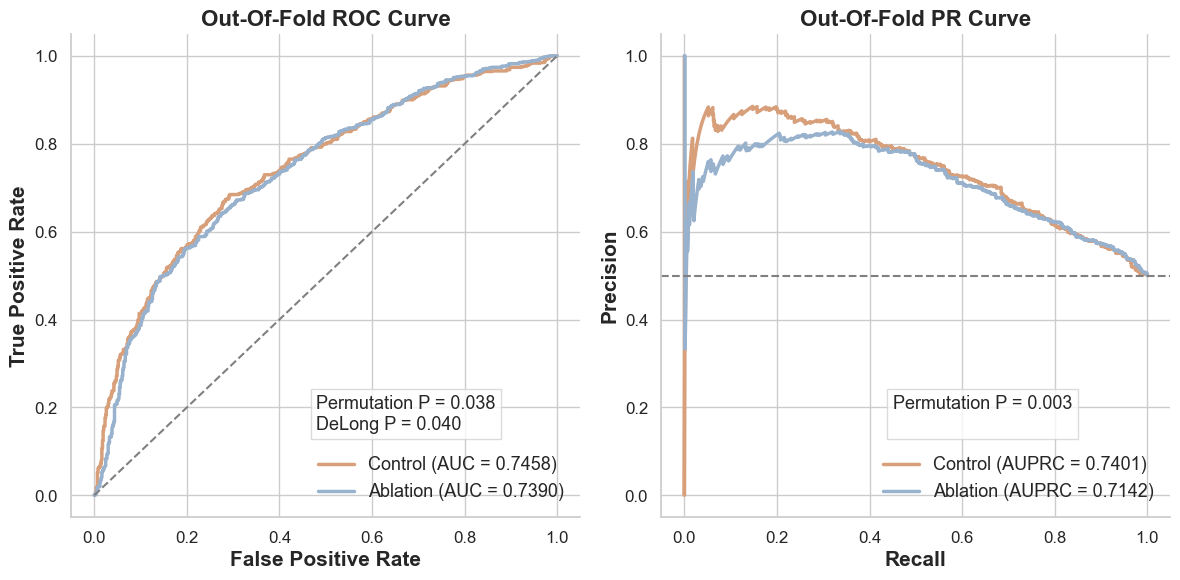

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve
import os

# 确保风格一致
sns.set_theme(style="whitegrid", font_scale=1.1)
custom_palette = [ "#D89F7B", "#98B2CD",] # Control, Ablation

# 创建输出目录变量（如果需要保存）
# output_dir_vis = base_dir_ablation # 如果你定义了的话，或者当前目录 "./"
output_dir_vis = "."

# ==========================================
# 图 1: OOF ROC & PR 曲线
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 计算曲线坐标
fpr_A, tpr_A, _ = roc_curve(y_true, preds_A)
fpr_B, tpr_B, _ = roc_curve(y_true, preds_B)
prec_A, rec_A, _ = precision_recall_curve(y_true, preds_A)
prec_B, rec_B, _ = precision_recall_curve(y_true, preds_B)

# --- Subplot 1: ROC Curve ---
ax1 = axes[0]
ax1.plot(fpr_A, tpr_A, color=custom_palette[0], lw=2.5, 
         label=f'Control (AUC = {auc_control:.4f})')
ax1.plot(fpr_B, tpr_B, color=custom_palette[1], lw=2.5, 
         label=f'Ablation (AUC = {auc_ablation:.4f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
ax1.set_xlabel('False Positive Rate', fontsize=15, fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontsize=15, fontweight='bold')
ax1.set_title('Out-Of-Fold ROC Curve', fontsize=16, fontweight='bold')
# 添加 p-value 注释
p_text_roc = f"Permutation P = {p_val_perm_one_sided:.3f}\nDeLong P = 0.040"
ax1.text(0.48, 0.15, p_text_roc, fontsize=13, bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgray'))
ax1.legend(loc="lower right", fontsize=13, frameon=False)

# --- Subplot 2: PR Curve ---
ax2 = axes[1]
# PR基线 (正样本比例)
baseline = np.sum(y_true == 1) / len(y_true)
ax2.plot(rec_A, prec_A, color=custom_palette[0], lw=2.5, 
         label=f'Control (AUPRC = {auprc_control:.4f})')
ax2.plot(rec_B, prec_B, color=custom_palette[1], lw=2.5, 
         label=f'Ablation (AUPRC = {auprc_ablation:.4f})')
ax2.axhline(baseline, color='gray', lw=1.5, linestyle='--')
ax2.set_xlabel('Recall', fontsize=15, fontweight='bold')
ax2.set_ylabel('Precision', fontsize=15, fontweight='bold')
ax2.set_title('Out-Of-Fold PR Curve', fontsize=16, fontweight='bold')
# 添加 p-value 注释
p_text_pr = f"Permutation P = {p_val_perm_one_sided_auprc:.3f}\n"
ax2.text(0.45, 0.15, p_text_pr, fontsize=13, bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgray'))
ax2.legend(loc="lower right", fontsize=13, frameon=False)

sns.despine()
plt.tight_layout()
fig1_path = os.path.join(output_dir_vis, "OOF_ROC_PR_Curves.png")
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.show()



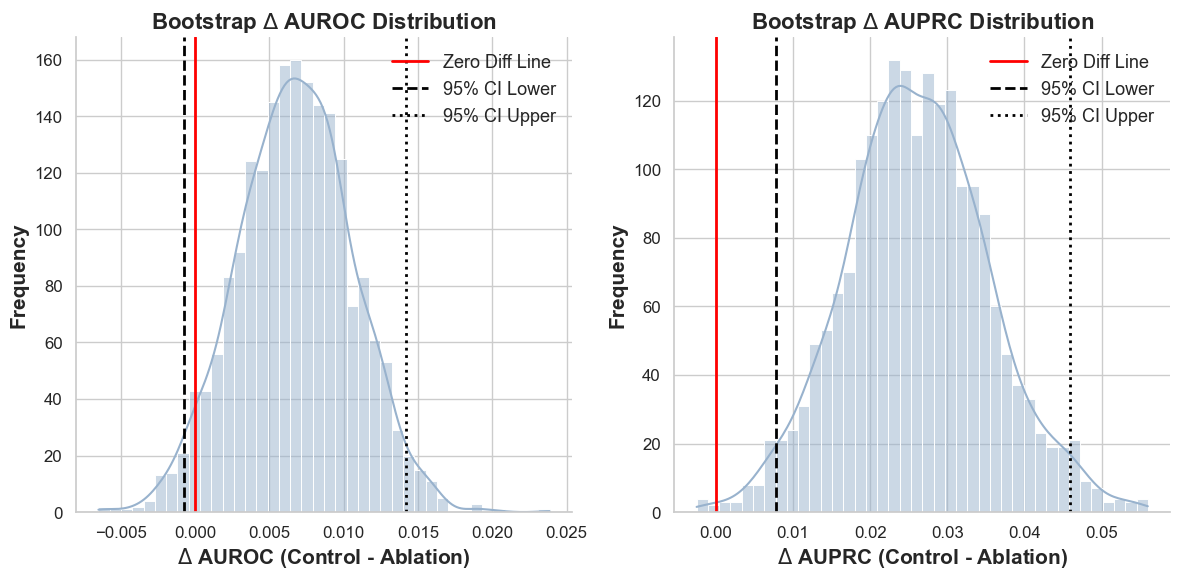

In [18]:
# ==========================================
# 图 2: Bootstrap $\Delta$ Distribution (可视化置信区间)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 使用漂亮的单一颜色填充直方图
hist_color = "#98B2CD"

# --- Subplot 1: Delta AUROC ---
ax3 = axes[0]
sns.histplot(bootstrapped_deltas, bins=40, kde=True, color=hist_color, ax=ax3, edgecolor='white')
ax3.axvline(0, color='red', linestyle='-', lw=2, label='Zero Diff Line')
ax3.axvline(ci_lower, color='black', linestyle='--', lw=2, label='95% CI Lower')
ax3.axvline(ci_upper, color='black', linestyle=':', lw=2, label='95% CI Upper')
ax3.set_xlabel('$\Delta$ AUROC (Control - Ablation)', fontsize=15, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=15, fontweight='bold')
ax3.set_title('Bootstrap $\Delta$ AUROC Distribution', fontsize=16, fontweight='bold')
ax3.legend(fontsize=13, frameon=False)

# --- Subplot 2: Delta AUPRC ---
ax4 = axes[1]
sns.histplot(bootstrapped_deltas_auprc, bins=40, kde=True, color=hist_color, ax=ax4, edgecolor='white')
ax4.axvline(0, color='red', linestyle='-', lw=2, label='Zero Diff Line')
ax4.axvline(ci_lower_auprc, color='black', linestyle='--', lw=2, label='95% CI Lower')
ax4.axvline(ci_upper_auprc, color='black', linestyle=':', lw=2, label='95% CI Upper')
ax4.set_xlabel('$\Delta$ AUPRC (Control - Ablation)', fontsize=15, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=15, fontweight='bold')
ax4.set_title('Bootstrap $\Delta$ AUPRC Distribution', fontsize=16, fontweight='bold')
ax4.legend(fontsize=13, frameon=False)

sns.despine()
plt.tight_layout()
fig2_path = os.path.join(output_dir_vis, "Bootstrap_Delta_Distributions.png")
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.show()

Plot saved to: /lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/circRNA_ligated_ablation/ligated_ablation_extra4fold_output/RandomForest_Metrics_Boxplot.png


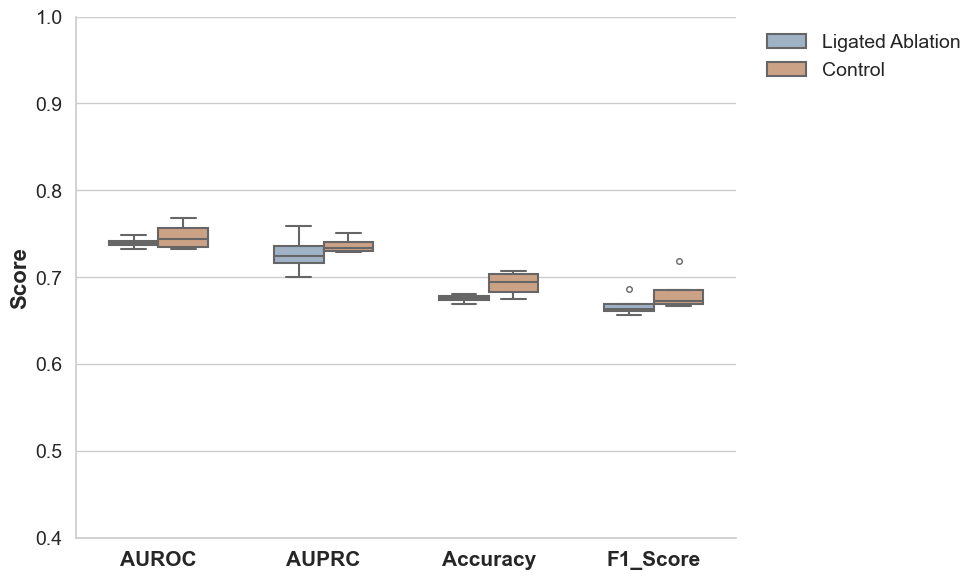

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 定义路径
base_dir_ablation = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/circRNA_ligated_ablation/ligated_ablation_extra4fold_output"
base_dir_control = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/ML_models/circRNA_ML_Model_tridivided_extra4fold_Output"

# 只选择 RandomForest
target_model = "RandomForest"
metrics_to_plot = ["AUROC", "AUPRC", "Accuracy", "F1_Score"]

data_list = []

# --- 1. 读取数据 ---
# 实验组
path_ablation = os.path.join(base_dir_ablation, target_model, "All_Folds_Evaluate_Results.csv")
if os.path.exists(path_ablation):
    df_abl = pd.read_csv(path_ablation)
    for metric in metrics_to_plot:
        for val in df_abl[metric]:
            data_list.append({"Group": "Ligated Ablation", "Metric": metric, "Value": val})
            
# 对照组
path_control = os.path.join(base_dir_control, target_model, "All_Folds_Evaluate_Results.csv")
if os.path.exists(path_control):
    df_ctrl = pd.read_csv(path_control)
    for metric in metrics_to_plot:
        for val in df_ctrl[metric]:
            data_list.append({"Group": "Control", "Metric": metric, "Value": val})

# 转换为 DataFrame
df_all = pd.DataFrame(data_list)
# 转换为 DataFrame
df_all = pd.DataFrame(data_list)

# --- 2. 绘图 ---
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", font_scale=1.1)

# 自定义配色
custom_palette = ["#98B2CD", "#D89F7B"]

# 绘制箱线图
ax = sns.boxplot(
    data=df_all, 
    x="Metric", 
    y="Value", 
    hue="Group", 
    palette=custom_palette,
    width=0.6,
    fliersize=4,
    linewidth=1.5
)

# 去除顶部和右侧边框（可选项，增加美观度）
sns.despine()

# 图表装饰
# plt.title('Random Forest Performance Comparison (4-Fold CV)', fontsize=16)
plt.ylabel('Score', fontsize=16, fontweight='bold')
plt.xlabel('') # 隐藏X轴的默认标题，整体更简洁
plt.xticks(fontsize=15, fontweight='bold')
plt.yticks(fontsize=14)
plt.ylim(0.4, 1.0)  # y轴最高控制到1

# 美化图例
plt.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=14)
plt.tight_layout()

# 保存并显示
output_png = os.path.join(base_dir_ablation, "RandomForest_Metrics_Boxplot.png")
plt.savefig(output_png, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {output_png}")
plt.show()